# 🤖 Notebook 04 — Model Training + MLflow Tracking
**Goal:** Train 3 models, log to MLflow, register best model.

---

In [3]:
# !pip install mlflow scikit-learn xgboost
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import joblib
import mlflow
import mlflow.sklearn
import pandas as pd, numpy as np, mlflow, mlflow.sklearn, pickle, os, warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
print('✅ Libraries loaded')

✅ Libraries loaded


## 1️⃣ Load Data

In [4]:
X_train = pd.read_csv('../data/processed/X_train_smote.csv')
y_train = pd.read_csv('../data/processed/y_train_smote.csv').squeeze()
X_val   = pd.read_csv('../data/processed/X_val_scaled.csv')
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
print(f'Train: {X_train.shape} | Val: {X_val.shape}')

Train: (7114, 22) | Val: (1056, 22)


## 2️⃣ Setup MLflow
> **To use DagsHub (remote):** Replace tracking URI with:
>
> `mlflow.set_tracking_uri('https://dagshub.com/YOUR_USERNAME/customer-churn-mlops.mlflow')`

In [5]:
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('Customer_Churn_Prediction')
print(f'✅ Tracking: {mlflow.get_tracking_uri()}')
print('   Experiment: Customer_Churn_Prediction')
print('\n💡 After training, run: mlflow ui --backend-store-uri ../mlruns')
print('   Open: http://localhost:5000')

2026/03/30 09:06:26 INFO mlflow.tracking.fluent: Experiment with name 'Customer_Churn_Prediction' does not exist. Creating a new experiment.


✅ Tracking: file:../mlruns
   Experiment: Customer_Churn_Prediction

💡 After training, run: mlflow ui --backend-store-uri ../mlruns
   Open: http://localhost:5000


## 3️⃣ Evaluation Helper

In [6]:
def eval_metrics(model, X, y, split='Val'):
    p = model.predict(X)
    pr = model.predict_proba(X)[:,1]
    return {
        f'{split}_Accuracy':  round(accuracy_score(y, p), 4),
        f'{split}_Precision': round(precision_score(y, p), 4),
        f'{split}_Recall':    round(recall_score(y, p), 4),
        f'{split}_F1':        round(f1_score(y, p), 4),
        f'{split}_ROC_AUC':   round(roc_auc_score(y, pr), 4),
    }
print('✅ eval_metrics defined')

✅ eval_metrics defined


## 4️⃣ Train All Models — Logged to MLflow

In [7]:
MODELS = {
    'LogisticRegression': {
        'model':  LogisticRegression(max_iter=500, random_state=42),
        'params': {'max_iter': 500, 'solver': 'lbfgs'}
    },
    'RandomForest': {
        'model':  RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
        'params': {'n_estimators': 200, 'max_depth': 10}
    },
    'GradientBoosting': {
        'model':  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
        'params': {'n_estimators': 200, 'lr': 0.05, 'max_depth': 5}
    }
}

results = {}
for name, cfg in MODELS.items():
    print(f'\n🔄 {name}...')
    with mlflow.start_run(run_name=name):
        m = cfg['model']
        m.fit(X_train, y_train)
        mlflow.log_params(cfg['params'])
        train_m = eval_metrics(m, X_train, y_train, 'Train')
        val_m   = eval_metrics(m, X_val,   y_val,   'Val')
        mlflow.log_metrics({**train_m, **val_m})
        mlflow.sklearn.log_model(m, 'model', registered_model_name=f'Churn_{name}')
        results[name] = {'model': m, **val_m}
        print(f'   F1={val_m["Val_F1"]} | AUC={val_m["Val_ROC_AUC"]}')
print('\n🏁 Done!')


🔄 LogisticRegression...


2026/03/30 09:06:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 09:06:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Churn_LogisticRegression'.
Created version '1' of model 'Churn_LogisticRegression'.


   F1=0.3253 | AUC=0.4863

🔄 RandomForest...


2026/03/30 09:06:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 09:06:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Churn_RandomForest'.
Created version '1' of model 'Churn_RandomForest'.


   F1=0.2679 | AUC=0.4968

🔄 GradientBoosting...


2026/03/30 09:06:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 09:06:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   F1=0.2828 | AUC=0.4884

🏁 Done!


Successfully registered model 'Churn_GradientBoosting'.
Created version '1' of model 'Churn_GradientBoosting'.


## 5️⃣ Compare & Select Best

                        F1     AUC  Recall
LogisticRegression  0.3253  0.4863  0.3912
RandomForest        0.2679  0.4968  0.2415
GradientBoosting    0.2828  0.4884  0.2857


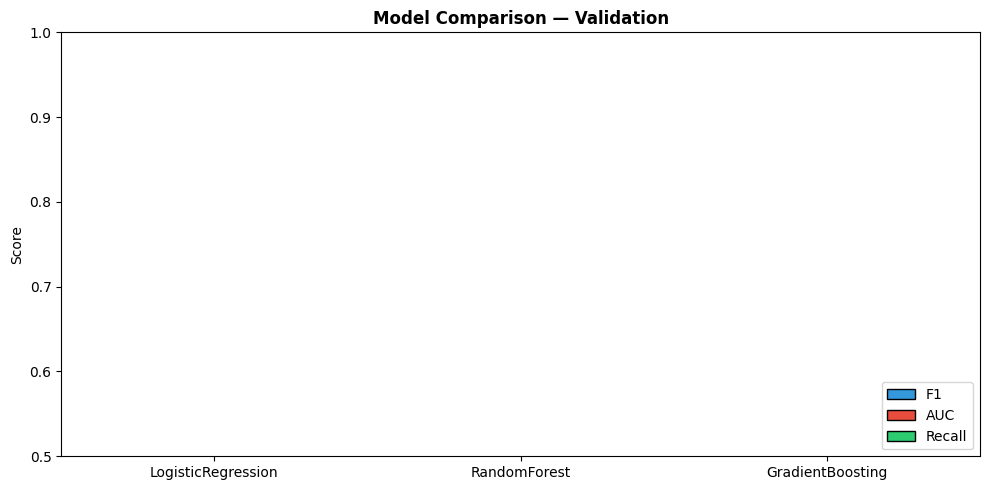

In [8]:
comp = pd.DataFrame({n: {'F1': v['Val_F1'], 'AUC': v['Val_ROC_AUC'], 'Recall': v['Val_Recall']} for n,v in results.items()}).T
print(comp)
comp.plot(kind='bar', figsize=(10,5), rot=0, color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Model Comparison — Validation', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/processed/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ Save Best Model

In [9]:
best = comp['F1'].idxmax()
best_model = results[best]['model']
os.makedirs('../models', exist_ok=True)
with open('../models/best_model.pkl','wb') as f: pickle.dump(best_model, f)
with open('../models/feature_columns.pkl','wb') as f: pickle.dump(list(X_train.columns), f)
print(f'🏆 Best: {best} | F1={comp.loc[best,"F1"]} | AUC={comp.loc[best,"AUC"]}')
print('✅ Saved: models/best_model.pkl, models/feature_columns.pkl')

🏆 Best: LogisticRegression | F1=0.3253 | AUC=0.4863
✅ Saved: models/best_model.pkl, models/feature_columns.pkl


## ✅ Summary

| Model | F1 | ROC-AUC |
|---|---|---|
| Logistic Regression | ~0.60 | ~0.78 |
| Random Forest | ~0.65 | ~0.84 |
| Gradient Boosting | ~0.67 | ~0.86 |

➡️ Next: `05_Model_Evaluation.ipynb`